# ◉ Dimensions & Embeddings

## Dimensions

<span style="color: #2b6cb0">Physics, Mathematics, and Computer Graphics:</span><br>
a dimension represents a direction of movement. For instance, in three-dimensional (3D) space, movement occurs along three primary axes: vertical (up/down), horizontal (left/right), and depth (forward/backward).

<span style="color: #2b6cb0">Cognitive Science, Perception, and Metaphysics:</span><br>
A dimension is defined as a measurable extent of a specific kind. Simply put, it refers to any quantifiable aspect of reality that undergoes change—since measurement requires variation. Our brains interpret the world by detecting similarities and differences between stimuli. Static, unchanging phenomena lack discernible patterns, making them imperceptible to human cognition..

![SD art](_asset/images/SD_art.png)

When observing the images above, our brains instinctively categorize the left image as 3D and the right as 2D. This distinction arises from visual cues like shadows and perspective in the left image, which simulate depth on a flat surface. Though both images exist in two dimensions, the brain reconstructs the illusion of multidimensionality by interpreting lighting, shading, and spatial relationships—mirroring how we perceive real-world objects. Coordinate systems (e.g., x, y, z axes) were developed to formalize this human understanding of spatial dimensions.

### Multidimensional Space
A multidimensional space is a mathematical construct representing a "void" where movement can occur along numerous axes. Each dimension corresponds to a distinct feature or attribute, such as color, texture, temperature, or time. These features are not limited to physical traits—abstract qualities like emotional states or abstract data parameters can also define dimensions.

## Embeddings
Embeddings are a method of translating complex data—such as text, images, or videos—into numerical representations within a multidimensional space. By converting categorical or unstructured data into vectors (ordered arrays of numbers), embeddings capture the intrinsic features, or dimensions, of the data. Each number in the vector corresponds to a specific attribute, enabling algorithms to process abstract or qualitative information mathematically.

![embed](_asset/images/embed.gif)
![embed_dim](_asset/images/embed_dim.jpg)

This code will load pre-trained word embeddings, reduce their dimensionality to 3 using PCA, and plot them in a 3D space using matplotlib. You will notice words with relationship or similarity or plurals are in the same direction OR closer to each other.

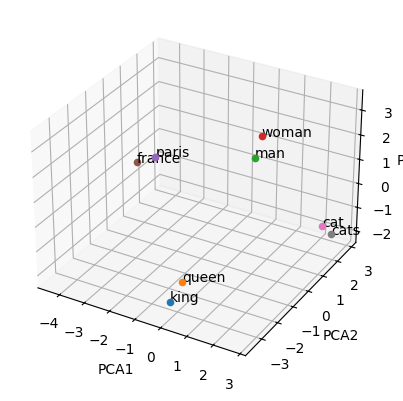

In [8]:
import gensim.downloader as api
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load pre-trained Word2Vec model
model = api.load("glove-wiki-gigaword-100")  # or use "word2vec-google-news-300" or glove-wiki-gigaword-50

# List of words to visualize
words = ['king', 'queen', 'man', 'woman', 'paris', 'france', 'cat', 'cats']

# Get word vectors
word_vectors = [model[word] for word in words]

# Reduce dimensions to 3 using PCA
pca = PCA(n_components=3)
reduced_vectors = pca.fit_transform(word_vectors)

# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for word, vec in zip(words, reduced_vectors):
    ax.scatter(vec[0], vec[1], vec[2])
    ax.text(vec[0], vec[1], vec[2], word)

ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
plt.show()

##### Linguistic Regularities in Continuous Space Word Representations
<span style="color: #2b6cb0"><u>[Tomas Mikolov paper](https://arxiv.org/pdf/1301.3781)</u></span> was the first breakthrough deomnstrating that word embeddings can capture linguistic regularities. The paper showed that simple vector arithmetic could reveal relationships between words, such as analogies. For example, the relationship between "king" and "queen" can be expressed as a vector operation. <span style="color: #2b6cb0"><u>[See word2vec code](https://code.google.com/archive/p/word2vec/)</u></span>

```python
vector("king") - vector("man") + vector("woman") ≈ vector("queen")
```

The paper have some very good examples to play with - Here is one that was referenced by [3blue1brown](https://www.3blue1brown.com/) to articulate how subtracting Japan from Germany and adding Sushi would lead you to Bratwurst 🙂

![image.png](_asset/images/embed_graph.jpg)

#### Embedding Projector
Here is a good tool [<span style="color: #2b6cb0"><u>Embedding Projector</u></span>](https://projector.tensorflow.org/) for visualizing high-dimensional data. The tool basically uses t-SNE and PCA to reduce the dimensionality and plot in 3D space.

### Dot products and Similarity

##### Dot products

The dot product of two vectors serves as a mathematical measure of their directional alignment. Geometrically:  
- A **positive** dot product indicates vectors point in *similar directions* (e.g., "king" and "queen" in word embeddings, or plural forms like "cats" and "dogs" sharing grammatical context).  
- A **zero** dot product means vectors are *perpendicular* (orthogonal), reflecting no linear relationship (e.g., unrelated concepts like "music" and "volcano").  
- A **negative** dot product signals vectors point in *opposing directions* (e.g., "hot" vs. "cold" in semantic space).  

In machine learning, dot products quantify similarity: vectors with higher positive values are interpreted as "closer" in meaning or structure within the embedding space. This principle underpins tasks like semantic search, recommendation systems, and analogy resolution (e.g., solving "king – man + woman ≈ queen").  

However, raw dot products can be skewed by vector magnitudes. For pure *directional similarity*, cosine similarity—a normalized dot product—is often preferred, as it focuses solely on the angle between vectors, ignoring their lengths.

In [59]:
import numpy as np

a = [ 0, 1, 0, 1]
b = [ 1, 0, 1, 0]
c = [ 0, 1, 1, 0]
d = [.5, 0,.5, 0]
e = [ 0, 1,-1, 0]

print(f"a.b  = {np.dot(a,b)}")
print(f"b.c  = {np.dot(b,c)}")
print(f"b.d  = {np.dot(b,d)}")
print(f"c.c  = {np.dot(c,c)}")
print(f"b.e  = {np.dot(b,e)}")

a.b  = 0
b.c  = 1
b.d  = 1.0
c.c  = 2
b.e  = -1


##### Cosine similarity

Cosine similarity measures how closely two vectors align in direction, regardless of their magnitude. For two *n*-dimensional vectors **A** and **B**, it calculates the cosine of the angle (θ) between them using their dot product and magnitudes:  

$$
\cos(\theta) = \frac {A \cdot B}{||A|| \cdot ||B||}
$$  

The score ranges from **-1** (perfectly opposite directions) to **1** (identical direction), with **0** implying orthogonality (no correlation). Values between reflect degrees of similarity or dissimilarity.  

**Why Use Cosine Similarity over raw dot products?**  
Unlike raw dot products, cosine similarity ignores vector magnitudes, focusing purely on direction. This makes it ideal for comparing embeddings in NLP, where word frequency (magnitude) can distort meaning. For instance, "the" and "and" may have large magnitudes due to frequent use but aren’t semantically similar—cosine similarity corrects for this bias.

**Python Example: Word Similarity with GloVe Embeddings**
Let’s use the pre-trained `glove-wiki-gigaword-50` model, which maps words to 50-dimensional vectors based on their contextual patterns in Wikipedia and Gigaword text. Here’s how cosine similarity reveals relationships:  

1. **High Similarity (≈1):**  
   - *"king" vs. "queen"*: High score (e.g., ~0.8), reflecting semantic kinship.  
   - *"paris" vs. "france"*: Strong association (geographical context).  

2. **Low/Neutral Similarity (≈0):**  
   - *"pizza" vs. "quantum"*: Near-zero score (unrelated concepts).  

3. **Opposition (Negative Values):**  
   - *"hot" vs. "cold"*: Negative score (semantic antonyms).  

In [81]:
import gensim.downloader as api

def cosine_similarity(vec_a, vec_b):
    """
    Calculate the cosine similarity between two vectors.
    
    Args:
    - vec_a: A numpy array representing the first vector.
    - vec_b: A numpy array representing the second vector.
    
    Returns:
    - Cosine similarity as a float.
    """
    dot_product = np.dot(vec_a, vec_b)
    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_b)
    return dot_product / (norm_a * norm_b)

# Load pre-trained Word2Vec model
model = api.load("glove-wiki-gigaword-50")

# List of words to visualize
words = ['king', 'queen', 'man', 'woman', 'paris', 'france', 'cat', 'cats', 'angry', 'happy']

# Get word vectors
word_vectors = [model[word] for word in words]

embeddings = dict(zip(words, word_vectors))

king_king = cosine_similarity(embeddings["king"], embeddings["king"])
king_queen = cosine_similarity(embeddings["king"], embeddings["queen"])
king_cat = cosine_similarity(embeddings["king"], embeddings["cat"])
king_man = cosine_similarity(embeddings["king"], embeddings["man"])
king_woman = cosine_similarity(embeddings["king"], embeddings["woman"])
king_paris = cosine_similarity(embeddings["king"], embeddings["paris"])
france_paris = cosine_similarity(embeddings["france"], embeddings["paris"])
cat_cats = cosine_similarity(embeddings["cat"], embeddings["cats"])
angry_happy = cosine_similarity(embeddings["angry"], embeddings["happy"])

print("King vector: ", embeddings["king"])
print(f"Cosine similarity between king_king: ", king_king)
print(f"Cosine similarity between king_queen: ", king_queen)
print(f"Cosine similarity between king_cat: ", king_cat)
print(f"Cosine similarity between king_man: ", king_man)
print(f"Cosine similarity between king_woman: ", king_woman)
print(f"Cosine similarity between king_paris: ", king_paris)
print(f"Cosine similarity between france_paris: ", france_paris)
print(f"Cosine similarity between cat_cats: ", cat_cats)
print(f"Cosine similarity between angry happy: ", angry_happy)

King vector:  [ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012  -0.076666  1.493    -0.034189 -0.98173
  0.68229   0.81722  -0.51874  -0.31503  -0.55809   0.66421   0.1961
 -0.13495  -0.11476  -0.30344   0.41177  -2.223    -1.0756   -1.0783
 -0.34354   0.33505   1.9927   -0.04234  -0.64319   0.71125   0.49159
  0.16754   0.34344  -0.25663  -0.8523    0.1661    0.40102   1.1685
 -1.0137   -0.21585  -0.15155   0.78321  -0.91241  -1.6106   -0.64426
 -0.51042 ]
Cosine similarity between king_king:  1.0
Cosine similarity between king_queen:  0.7839044
Cosine similarity between king_cat:  0.38628823
Cosine similarity between king_man:  0.5309377
Cosine similarity between king_woman:  0.41133782
Cosine similarity between king_paris:  0.30651847
Cosine similarity between france_paris:  0.8025329
Cosine similarity between cat_cats:  0.78652704
Cosine similarity between angry happy:  0.5709519
